In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,root_mean_squared_error,confusion_matrix,roc_auc_score,log_loss
from sklearn.metrics import f1_score,accuracy_score,recall_score,precision_score,classification_report
from tqdm import tqdm
import os
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler,PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
import datetime as dt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import BernoulliNB,GaussianNB

In [4]:
iris = pd.read_csv(r"../Datasets/iris.csv")
iris

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [23]:

X = iris.drop('Species', axis=1)

y = iris['Species']
lda=LinearDiscriminantAnalysis().set_output(transform='pandas')
X_lda = lda.fit_transform(X,y)
lda_data = pd.concat([X_lda,y],axis=1)
lda_data

,lineardiscriminantanalysis0,lineardiscriminantanalysis1,Species
0,8.061800,-0.300421,0
1,7.128688,0.786660,0
2,7.489828,0.265384,0
3,6.813201,0.670631,0
4,8.132309,-0.514463,0
...,...,...,...
145,-5.645003,-1.677717,2
146,-5.179565,0.363475,2
147,-4.967741,-0.821141,2
148,-5.886145,-2.345091,2


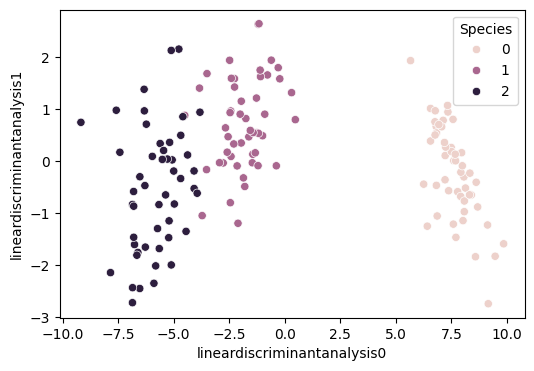

In [18]:
import seaborn as sns
fig=plt.figure(figsize=(6,4))
sns.scatterplot(data=lda_data, x='lineardiscriminantanalysis0',
               y = 'lineardiscriminantanalysis1', hue='Species',color="blue")
plt.show()

### Image Segmentation

In [25]:
imgseg = pd.read_csv(r'../Datasets/Image_Segmentation.csv')
imgseg

,Class,region.centroid.col,region.centroid.row,region.pixel.count,short.line.density.5,short.line.density.2,vedge.mean,vegde.sd,hedge.mean,hedge.sd,intensity.mean,rawred.mean,rawblue.mean,rawgreen.mean,exred.mean,exblue.mean,exgreen.mean,value.mean,saturation.mean,hue-mean
0,BRICKFACE,188,133,9,0.000000,0.0,0.333333,0.266667,0.500000,0.077778,6.666666,8.333334,7.777778,3.888889,5.000000,3.333333,-8.333333,8.444445,0.538580,-0.924817
1,BRICKFACE,105,139,9,0.000000,0.0,0.277778,0.107407,0.833333,0.522222,6.111111,7.555555,7.222222,3.555556,4.333334,3.333333,-7.666666,7.555555,0.532628,-0.965946
2,BRICKFACE,34,137,9,0.000000,0.0,0.500000,0.166667,1.111111,0.474074,5.851852,7.777778,6.444445,3.333333,5.777778,1.777778,-7.555555,7.777778,0.573633,-0.744272
3,BRICKFACE,39,111,9,0.000000,0.0,0.722222,0.374074,0.888889,0.429629,6.037037,7.000000,7.666666,3.444444,2.888889,4.888889,-7.777778,7.888889,0.562919,-1.175773
4,BRICKFACE,16,128,9,0.000000,0.0,0.500000,0.077778,0.666667,0.311111,5.555555,6.888889,6.666666,3.111111,4.000000,3.333333,-7.333334,7.111111,0.561508,-0.985811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,GRASS,36,243,9,0.111111,0.0,1.888889,1.851851,2.000000,0.711110,13.333333,9.888889,12.111111,18.000000,-10.333333,-3.666667,14.000000,18.000000,0.452229,2.368311
205,GRASS,186,218,9,0.000000,0.0,1.166667,0.744444,1.166667,0.655555,13.703704,10.666667,12.666667,17.777779,-9.111111,-3.111111,12.222222,17.777779,0.401347,2.382684
206,GRASS,197,236,9,0.000000,0.0,2.444444,6.829628,3.333333,7.599998,16.074074,13.111111,16.666668,18.444445,-8.888889,1.777778,7.111111,18.555555,0.292729,2.789800
207,GRASS,208,240,9,0.111111,0.0,1.055556,0.862963,2.444444,5.007407,14.148149,10.888889,13.000000,18.555555,-9.777778,-3.444444,13.222222,18.555555,0.421621,2.392487


In [29]:
X = imgseg.drop("Class", axis=1)
y = imgseg['Class']
lda=LinearDiscriminantAnalysis().set_output(transform='pandas')
X_lda = lda.fit_transform(X,y)
lda_data = pd.concat([X_lda,y],axis=1)
lda_data

,lineardiscriminantanalysis0,lineardiscriminantanalysis1,lineardiscriminantanalysis2,lineardiscriminantanalysis3,lineardiscriminantanalysis4,lineardiscriminantanalysis5,Class
0,0.589119,4.278844,0.857238,1.634340,-0.587506,0.759482,BRICKFACE
1,0.450417,4.154446,0.459624,1.236909,-1.166816,1.079905,BRICKFACE
2,2.091867,4.449199,0.593436,1.722328,-2.273458,0.502685,BRICKFACE
3,0.150416,4.506612,-0.735878,1.487779,-1.506069,0.678258,BRICKFACE
4,0.823607,4.340618,-0.283745,1.378150,-1.922957,0.877237,BRICKFACE
...,...,...,...,...,...,...,...
204,14.752466,-1.865171,0.848495,-1.360536,-0.684546,-0.427048,GRASS
205,13.371916,-1.384433,0.535600,-0.313078,0.473139,0.748171,GRASS
206,12.179366,-1.335292,0.740998,-0.099776,-0.329551,2.453837,GRASS
207,14.056916,-1.956963,1.548653,-1.128665,0.749780,-0.071865,GRASS


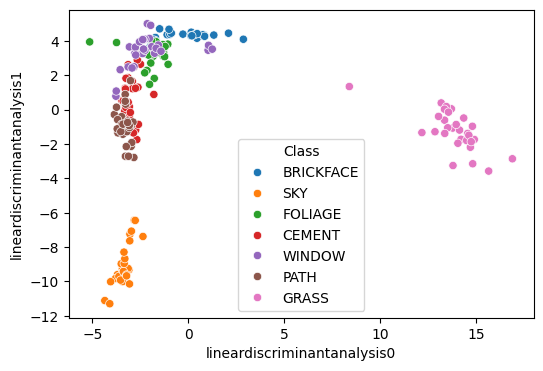

In [33]:
import seaborn as sns
fig=plt.figure(figsize=(6,4))
sns.scatterplot(data=lda_data, x='lineardiscriminantanalysis0',
               y = 'lineardiscriminantanalysis1', hue='Class',color="blue")
plt.show()